In [11]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Large normal data
normal_temp = np.random.normal(15, 5, 5000)
normal_pressure = np.random.normal(101, 10, 5000)
normal_radiation = np.random.normal(50, 10, 5000)

# Large anomaly data
anom_temp = np.random.normal(35, 8, 1000)
anom_pressure = np.random.normal(80, 15, 1000)
anom_radiation = np.random.normal(110, 25, 1000)
# Combine
X = np.vstack([
    np.column_stack((normal_temp, normal_pressure, normal_radiation)),
    np.column_stack((anom_temp, anom_pressure, anom_radiation))
])

y = np.array([0]*5000 + [1]*1000)

data = pd.DataFrame(X, columns=["Temperature", "Pressure", "Radiation"])
data["Label"] = y

print("Dataset size:", data.shape)
data.head()

Dataset size: (6000, 4)


,Temperature,Pressure,Radiation,Label
0,17.483571,96.762403,43.215053,0
1,14.308678,96.465859,46.945005,0
2,18.238443,83.043568,44.026189,0
3,22.615149,97.699098,51.104180,0
4,13.829233,108.328291,61.971785,0


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X = data[["Temperature", "Pressure", "Radiation"]]
y = data["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
model = RandomForestClassifier(n_estimators=200, max_depth=10)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9975
Confusion Matrix:
 [[1003    1]
 [   2  194]]


In [13]:
import time
import pandas as pd

print("Real-time anomaly detection simulation:\n")

# Fit the model here to resolve the NotFittedError
model.fit(X_train, y_train)

for i in range(5):
    new_sample_list = [
        np.random.normal(20, 10),
        np.random.normal(90, 15),
        np.random.normal(60, 20)
    ]
    # Convert the new sample to a DataFrame with feature names
    new_sample = pd.DataFrame([new_sample_list], columns=X_train.columns)

    prediction = model.predict(new_sample)

    print("Input:", new_sample_list)

    if prediction[0] == 0:
        print("Result: Normal\n")
    else:
        print("Result: Anomaly Detected!\n")

    time.sleep(1)
    print("Total samples:", len(data))

Real-time anomaly detection simulation:

Input: [13.531354762804249, 69.58389900035789, 70.04509191757398]
Result: Anomaly Detected!

Total samples: 6000
Input: [27.027931085810877, 91.1278436727118, 71.57232795475882]
Result: Anomaly Detected!

Total samples: 6000
Input: [11.48000079144456, 104.08947005034742, 83.4343742303954]
Result: Normal

Total samples: 6000
Input: [30.2068178449596, 91.85952849233227, 83.72988080132038]
Result: Anomaly Detected!

Total samples: 6000
Input: [8.571318764684712, 98.60208205372716, 74.32900184069209]
Result: Normal

Total samples: 6000


Test Input: [[45, 60, 130]]
Result: Anomaly Detected!


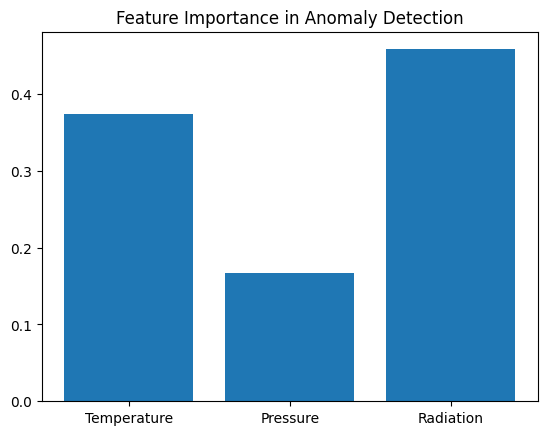

In [16]:
# Test anomaly case
new_data = pd.DataFrame([[45, 60, 130]],
                        columns=["Temperature", "Pressure", "Radiation"])
prediction = model.predict(new_data)
print("Test Input:", test_anomaly)

if prediction[0] == 0:
    print("Result: Normal")
else:
    print("Result: Anomaly Detected!")
    import matplotlib.pyplot as plt

importance = model.feature_importances_
features = ["Temperature", "Pressure", "Radiation"]

plt.bar(features, importance)
plt.title("Feature Importance in Anomaly Detection")
plt.show()